In [1]:
# prepare_data.py
import pandas as pd

# Загружаем данные
X = pd.read_csv('anxiety_train_x.csv')
y = pd.read_csv('anxiety_train_y.csv')

# Объединяем в один датафрейм (предполагаем, что строки идут в одинаковом порядке)
df = pd.concat([X, y], axis=1)
df.columns = ['text', 'label']

# Проверяем баланс классов
print("Распределение классов:")
print(df['label'].value_counts())

# Сохраняем для обучения
df.to_csv('training_data.csv', index=False)
print(f"Сохранено {len(df)} записей в training_data.csv")

Распределение классов:
label
ТРЕВОЖНОСТЬ        266
НЕТ ТРЕВОЖНОСТИ    227
Name: count, dtype: int64
Сохранено 493 записей в training_data.csv


In [1]:
# train_classic.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from datasets import Dataset, DatasetDict
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    TaskType,
)
import gc
import os

# Отключаем предупреждения
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ============================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================
print("📊 Подготовка данных...")
df = pd.read_csv('training_data.csv')

print(f"Загружено {len(df)} записей")
print(f"Распределение классов:\n{df['label'].value_counts()}")

# Приводим метки к стандартному виду
def normalize_label(label):
    label = str(label).upper().strip()
    if 'ТРЕВОЖНОСТЬ' in label:
        return 'ТРЕВОЖНОСТЬ'
    return 'НЕТ ТРЕВОЖНОСТИ'

df['label'] = df['label'].apply(normalize_label)

system_prompt = "Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:\nДиагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]\nОбоснование: [1 предложение]"

# Функция для обоснований
def get_rationale(label):
    if label == 'ТРЕВОЖНОСТЬ':
        options = [
            "В тексте выявлены явные маркеры тревожного состояния: беспокойство, напряжение, избегание.",
            "Наблюдаются характерные признаки тревожности: навязчивые мысли, физическое напряжение.",
            "Текст содержит паттерны катастрофизации и повышенной тревожности.",
        ]
    else:
        options = [
            "В тексте отсутствуют признаки патологической тревожности, эмоциональный фон в норме.",
            "Сообщение не содержит маркеров тревожного расстройства.",
            "Признаки тревожности не выявлены, состояние в пределах нормы.",
        ]
    return np.random.choice(options)

# Формируем данные для обучения
formatted_data = []
for _, row in df.iterrows():
    text = row['text']
    label = row['label']
    
    # Формат: system + user + assistant
    formatted_text = f"""<|im_start|>system
{system_prompt}<|im_end|>
<|im_start|>user
{text[:1024]}<|im_end|>
<|im_start|>assistant
Диагноз: {label}
Обоснование: {get_rationale(label)}<|im_end|>"""
    
    formatted_data.append({"text": formatted_text})

# Разделяем на train/val
train_data, val_data = train_test_split(formatted_data, test_size=0.1, random_state=42)

dataset = DatasetDict({
    'train': Dataset.from_list(train_data),
    'validation': Dataset.from_list(val_data)
})

print(f"Train: {len(dataset['train'])}, Val: {len(dataset['validation'])}")

# ============================================
# 2. ЗАГРУЗКА МОДЕЛИ И ТОКЕНИЗАТОРА
# ============================================
print("\n🤖 Загружаю модель Qwen 2.5 7B...")

model_name = "Qwen/Qwen2.5-7B-Instruct"

# Конфигурация квантования
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Загружаем токенизатор
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True,
    padding_side="right",
)
tokenizer.pad_token = tokenizer.eos_token

# Загружаем модель
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",  # Экономит память
)

# Подготавливаем модель для k-bit обучения
model = prepare_model_for_kbit_training(model)

# ============================================
# 3. КОНФИГУРАЦИЯ LoRA
# ============================================
print("🔧 Настройка LoRA...")

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ============================================
# 4. ТОКЕНИЗАЦИЯ ДАННЫХ
# ============================================
print("📝 Токенизация данных...")

def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=768,  # Оптимально для 12GB VRAM
        return_tensors=None,
    )
    # Для causal LM labels = input_ids
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset["train"].column_names,
    num_proc=1,  # На Windows лучше 1
)

# ============================================
# 5. ПАРАМЕТРЫ ОБУЧЕНИЯ
# ============================================
print("⚙️ Настройка обучения...")

training_args = TrainingArguments(
    output_dir="./anxiety_model_classic",
    
    # Эпохи и шаги
    num_train_epochs=3,
    
    # Размер батча (оптимизировано для 12GB)
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,  # Эффективный batch=8
    
    # Оптимизация
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=10,
    optim="adamw_8bit",
    weight_decay=0.01,
    max_grad_norm=0.3,
    
    # Логирование и сохранение
    logging_steps=10,
    logging_dir="./logs",
    save_steps=100,
    save_total_limit=2,
    eval_strategy="steps",
    eval_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    
    # Типы данных
    fp16=False,
    bf16=True,  # RTX 4070 поддерживает bf16
    
    # Оптимизация памяти
    gradient_checkpointing=True,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    
    # Прочее
    seed=42,
    report_to="none",
    remove_unused_columns=False,
)

# ============================================
# 6. КОЛЛАТОР ДАННЫХ
# ============================================
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
    pad_to_multiple_of=8,
)

# ============================================
# 7. ЗАПУСК ОБУЧЕНИЯ
# ============================================
print("\n🚀 Запуск обучения...")
print("Это займет 15-30 минут...")

# Очистка памяти
torch.cuda.empty_cache()
gc.collect()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
)

trainer.train()

print("\n✅ Обучение завершено!")

# ============================================
# 8. СОХРАНЕНИЕ МОДЕЛИ
# ============================================
print("\n💾 Сохранение модели...")

# Сохраняем LoRA адаптеры
model.save_pretrained("./anxiety_model_lora_classic")
tokenizer.save_pretrained("./anxiety_model_lora_classic")

# Сохраняем полную модель (для Ollama)
print("🔄 Сохраняю полную модель...")
merged_model = model.merge_and_unload()
merged_model.save_pretrained("./anxiety_model_full_classic")
tokenizer.save_pretrained("./anxiety_model_full_classic")

print("✅ Модели сохранены!")

# ============================================
# 9. ТЕСТИРОВАНИЕ
# ============================================
print("\n🧪 Тестирование модели...")

model.eval()

def predict_anxiety(text):
    prompt = f"""<|im_start|>system
{system_prompt}<|im_end|>
<|im_start|>user
{text[:512]}<|im_end|>
<|im_start|>assistant
"""
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Извлекаем только ответ ассистента
    if "<|im_start|>assistant" in response:
        response = response.split("<|im_start|>assistant")[-1].strip()
    
    return response

# Тестовые примеры
test_texts = [
    "Я очень переживаю из-за завтрашнего собеседования, не могу уснуть уже неделю, постоянно прокручиваю worst-case сценарии",
    "Вчера ходил в кино с друзьями, был отличный фильм, всем рекомендую к просмотру",
    "Постоянно чувствую напряжение в теле, сердце бьется быстрее обычного, не могу расслабиться даже дома",
]

print("\n" + "="*70)
for text in test_texts:
    result = predict_anxiety(text)
    print(f"\n📝 Текст: {text[:80]}...")
    print(f"🏷️ Результат:\n{result}")
    print("-"*70)

# ============================================
# 10. ОЦЕНКА КАЧЕСТВА
# ============================================
print("\n📊 Оценка качества на валидации...")

predictions = []
true_labels = []

for item in val_data[:25]:  # Берем 25 примеров
    # Извлекаем текст пользователя
    user_text = item['text'].split("<|im_start|>user\n")[1].split("<|im_end|>")[0]
    # Извлекаем истинную метку
    true_label = 'ТРЕВОЖНОСТЬ' if 'ТРЕВОЖНОСТЬ' in item['text'] else 'НЕТ ТРЕВОЖНОСТИ'
    
    response = predict_anxiety(user_text)
    pred_label = 'ТРЕВОЖНОСТЬ' if 'ТРЕВОЖНОСТЬ' in response else 'НЕТ ТРЕВОЖНОСТИ'
    
    predictions.append(pred_label)
    true_labels.append(true_label)

print("\nРезультаты классификации:")
print(classification_report(true_labels, predictions, zero_division=0))
print("\n🎉 Обучение полностью завершено!")
print("📁 Модель сохранена в папках:")
print("   - anxiety_model_lora_classic/ (только LoRA адаптеры)")
print("   - anxiety_model_full_classic/ (полная модель)")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu130).
W0508 08:26:18.211000 23572 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


📊 Подготовка данных...
Загружено 493 записей
Распределение классов:
label
ТРЕВОЖНОСТЬ        266
НЕТ ТРЕВОЖНОСТИ    227
Name: count, dtype: int64
Train: 443, Val: 50

🤖 Загружаю модель Qwen 2.5 7B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

🔧 Настройка LoRA...
trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273
📝 Токенизация данных...


...


✅ Обучение завершено!

💾 Сохранение модели...
🔄 Сохраняю полную модель...


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\peft\tuners\lora\bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ Модели сохранены!

🧪 Тестирование модели...


📝 Текст: Я очень переживаю из-за завтрашнего собеседования, не могу уснуть уже неделю, по...
🏷️ Результат:
system
Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]
Обоснование: [1 предложение]
user
Я очень переживаю из-за завтрашнего собеседования, не могу уснуть уже неделю, постоянно прокручиваю worst-case сценарии
assistant
Диагноз: ТРЕВОЖНОСТЬ
Обоснование: Чрезмерное беспокойство о будущем событии, проблемы со сном и постоянное прокручивание негативных сценариев являются характерными признаками тревожности.
----------------------------------------------------------------------

📝 Текст: Вчера ходил в кино с друзьями, был отличный фильм, всем рекомендую к просмотру...
🏷️ Результат:
system
Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]
Обоснование: [

# Оценка

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu130).
W0509 13:39:44.432000 27960 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


📂 Загрузка тестовых данных...
Загружено тестовых примеров: 141

Распределение классов в тесте:
label
ТРЕВОЖНОСТЬ        76
НЕТ ТРЕВОЖНОСТИ    65
Name: count, dtype: int64

Процент положительных: 53.9%

🤖 Загрузка обученной модели...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ Загружена полная модель

🔮 Запуск предсказаний на 141 примерах...
Это может занять несколько минут...



...


📝 Пример 50:
Текст: Я думаю, что на картине изображена молодая женщина. Она размышляет о своей жизни, о будущем. И в ее ...
Истинная: НЕТ ТРЕВОЖНОСТИ | Предсказано: ТРЕВОЖНОСТЬ
Время: 9.29с


Предсказания:  71%|██████████████████████████████████████████████▊                   | 100/141 [14:14<05:13,  7.66s/it]


📝 Пример 100:
Текст: Много паники в мире, в стране не принимают адекватные меры для каждого гражданина РФ, для его благос...
Истинная: ТРЕВОЖНОСТЬ | Предсказано: ТРЕВОЖНОСТЬ
Время: 6.52с


Предсказания: 100%|██████████████████████████████████████████████████████████████████| 141/141 [19:08<00:00,  8.15s/it]



💾 Сохранение результатов...
✅ Результаты сохранены в prediction_results_raw.csv

📊 Вычисление метрик...

               РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ

📈 Основные метрики:
  Accuracy (точность):     0.3121 (31.21%)
  Precision (точность):    0.2558 (25.58%)
  Recall (полнота):        0.1447 (14.47%)
  Specificity:             0.5077 (50.77%)
  F1-score:                0.1849 (18.49%)
  ROC-AUC:                 0.5223

📊 Матрица ошибок:
  True Negatives:  33
  False Positives: 32
  False Negatives: 65
  True Positives:  11

⚡ Производительность:
  Среднее время предсказания: 8.144с
  Медианное время:           7.905с
  Min/Max:                  4.991с / 12.549с
  Всего примеров:           141

📋 Classification Report:
                 precision    recall  f1-score   support

НЕТ ТРЕВОЖНОСТИ       0.34      0.51      0.40        65
    ТРЕВОЖНОСТЬ       0.26      0.14      0.18        76

       accuracy                           0.31       141
      macro avg       0.30      0.33      0.29  

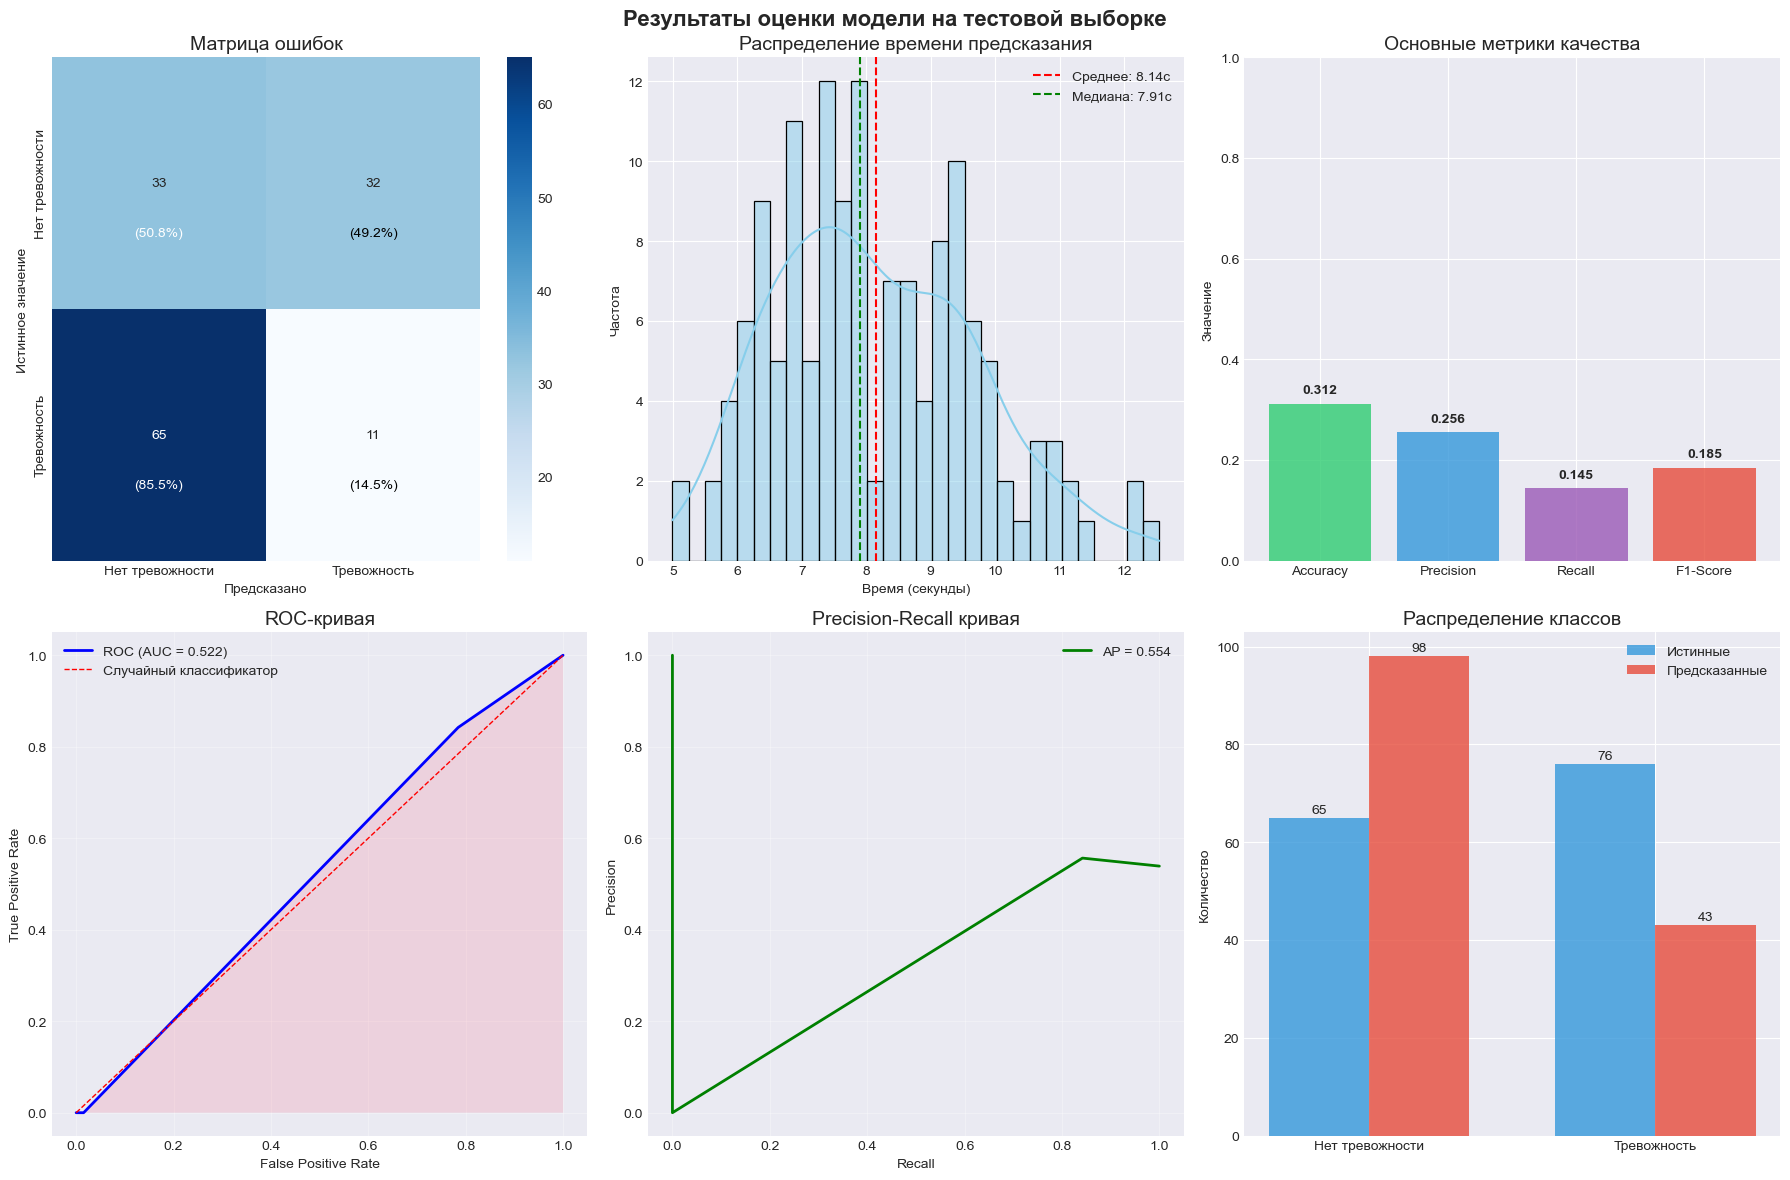


🔍 Анализ ошибок...


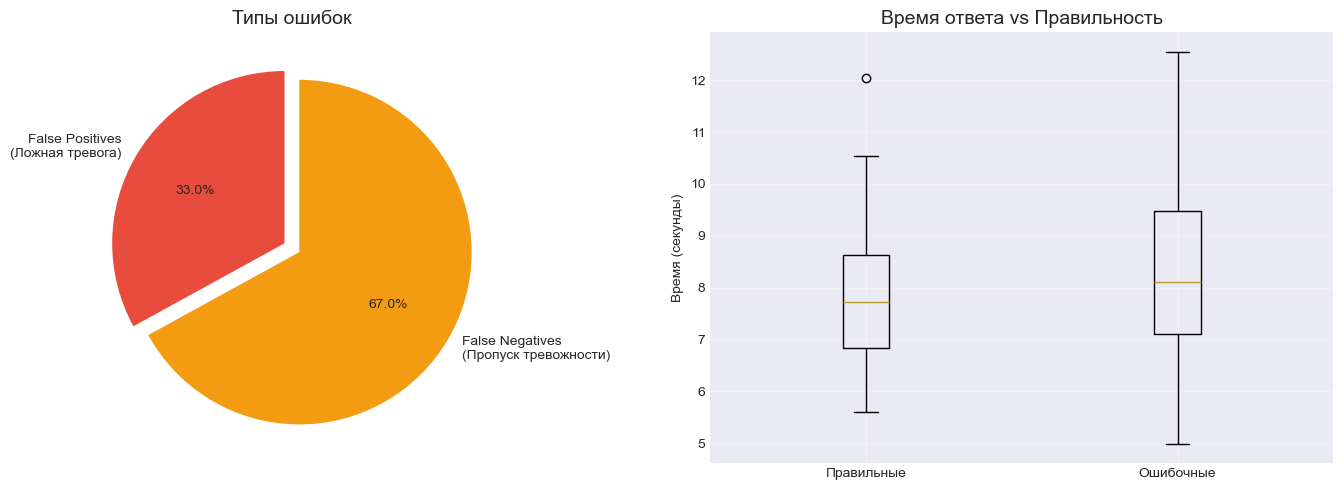


📝 Примеры ошибок модели:

Ложные срабатывания (False Positives) - модель предсказала тревожность, но её нет:

  Текст: Только что узнал о гибели известного профессора у нас в университете. Который уже случай, когда этот вирус забирает жизнь важного, талантливого, видно...
  Ответ модели: system
Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]...

  Текст: Приветствую тебя, мой дорогой друг! Я рада, наконец, написать тебе это письмо, так как мы давно не виделись и не знаем новостей друг друга. Первый мес...
  Ответ модели: system
Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]...

  Текст: Привет. Давно не общались, соскучилась по тебе  С твоим переездом, стало как-то скучно. Все время вспоминаю наши с тобой вечерние гулянки, что мы с то...
  Ответ модели: system
Ты клинический психолог. Определи, 

In [1]:
# evaluate_model.py
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from datetime import datetime
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ============================================
print("📂 Загрузка тестовых данных...")

# Загружаем тестовые данные
X_test = pd.read_csv('anxiety_test_x.csv')
y_test = pd.read_csv('anxiety_test_y.csv')

# Объединяем
df_test = pd.concat([X_test, y_test], axis=1)
df_test.columns = ['text', 'label']

print(f"Загружено тестовых примеров: {len(df_test)}")
print(f"\nРаспределение классов в тесте:")
print(df_test['label'].value_counts())
print(f"\nПроцент положительных: {df_test['label'].value_counts(normalize=True).get('ТРЕВОЖНОСТЬ', 0)*100:.1f}%")

# Нормализуем метки
def normalize_label(label):
    label = str(label).upper().strip()
    return 'ТРЕВОЖНОСТЬ' if 'ТРЕВОЖНОСТЬ' in label else 'НЕТ ТРЕВОЖНОСТИ'

df_test['label'] = df_test['label'].apply(normalize_label)

# ============================================
# 2. ЗАГРУЗКА ОБУЧЕННОЙ МОДЕЛИ
# ============================================
print("\n🤖 Загрузка обученной модели...")

# Системный промпт (такой же, как при обучении)
system_prompt = "Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:\nДиагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]\nОбоснование: [1 предложение]"

# Загружаем модель (выберите нужный путь)
model_path = "./anxiety_model_full_classic"  # или "./anxiety_model_lora_classic"

try:
    # Пробуем загрузить полную модель
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        device_map="auto",
        torch_dtype=torch.float16,
    )
    print("✅ Загружена полная модель")
except:
    try:
        # Если полной нет, загружаем базовую + LoRA
        base_model_name = "Qwen/Qwen2.5-7B-Instruct"
        tokenizer = AutoTokenizer.from_pretrained(base_model_name)
        model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            device_map="auto",
            torch_dtype=torch.float16,
        )
        model = PeftModel.from_pretrained(model, model_path)
        print("✅ Загружена LoRA модель")
    except:
        raise Exception("Не удалось загрузить модель. Проверьте путь!")

tokenizer.pad_token = tokenizer.eos_token
model.eval()

# ============================================
# 3. ФУНКЦИЯ ПРЕДСКАЗАНИЯ
# ============================================
def predict_anxiety(text, max_length=512):
    """Предсказание тревожности для одного текста"""
    prompt = f"""<|im_start|>system
{system_prompt}<|im_end|>
<|im_start|>user
{text[:max_length]}<|im_end|>
<|im_start|>assistant
"""
    
    inputs = tokenizer(
        prompt, 
        return_tensors="pt", 
        truncation=True, 
        max_length=max_length
    ).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Извлекаем ответ ассистента
    if "<|im_start|>assistant" in response:
        response = response.split("<|im_start|>assistant")[-1].strip()
    
    return response

def extract_prediction(full_response):
    """Извлекает предсказанную метку из ответа модели (только после assistant)"""
    # Ищем последнюю метку assistant
    if 'assistant' in full_response.lower():
        # Берём только часть после последнего 'assistant'
        last_assistant = full_response.split('assistant')[-1]
    else:
        last_assistant = full_response
    
    # Анализируем только последний ответ модели
    if 'ДИАГНОЗ: ТРЕВОЖНОСТЬ' in last_assistant.upper():
        return 'ТРЕВОЖНОСТЬ'
    elif 'ДИАГНОЗ: НЕТ ТРЕВОЖНОСТИ' in last_assistant.upper():
        return 'НЕТ ТРЕВОЖНОСТИ'
    else:
        # fallback для старых форматов без "Диагноз:"
        if 'ТРЕВОЖНОСТЬ' in last_assistant.upper() and 'НЕТ ТРЕВОЖНОСТИ' not in last_assistant.upper():
            return 'ТРЕВОЖНОСТЬ'
        return 'НЕТ ТРЕВОЖНОСТИ'

def get_confidence(response):
    """Оценивает уверенность модели на основе ответа"""
    # Простая эвристика: считаем уверенность на основе наличия ключевых слов
    if 'явные' in response.lower() or 'отсутствуют' in response.lower():
        return 0.9
    elif 'возможно' in response.lower() or 'вероятно' in response.lower():
        return 0.7
    else:
        return 0.8  # Базовая уверенность

# ============================================
# 4. ЗАПУСК ПРЕДСКАЗАНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ
# ============================================
print(f"\n🔮 Запуск предсказаний на {len(df_test)} примерах...")
print("Это может занять несколько минут...\n")

predictions = []
confidences = []
true_labels = []
response_times = []
raw_responses = []

# Прогресс-бар
for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Предсказания"):
    text = row['text']
    true_label = row['label']
    
    # Замеряем время предсказания
    start_time = time.time()
    response = predict_anxiety(text)
    end_time = time.time()
    
    # Извлекаем предсказание
    pred_label = extract_prediction(response)
    confidence = get_confidence(response)
    
    # Сохраняем результаты
    predictions.append(pred_label)
    confidences.append(confidence)
    true_labels.append(true_label)
    response_times.append(end_time - start_time)
    raw_responses.append(response)
    
    # Выводим пример каждые 50 предсказаний
    if (idx + 1) % 50 == 0:
        print(f"\n📝 Пример {idx+1}:")
        print(f"Текст: {text[:100]}...")
        print(f"Истинная: {true_label} | Предсказано: {pred_label}")
        print(f"Время: {end_time - start_time:.2f}с")

# ============================================
# 5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
print("\n💾 Сохранение результатов...")

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'text': df_test['text'],
    'true_label': true_labels,
    'predicted_label': predictions,
    'confidence': confidences,
    'response_time': response_times,
    'raw_response': raw_responses
})

# Сохраняем в CSV
results_df.to_csv('prediction_results_raw.csv', index=False)
print("✅ Результаты сохранены в prediction_results_raw.csv")

# ============================================
# 6. ВЫЧИСЛЕНИЕ МЕТРИК
# ============================================
print("\n📊 Вычисление метрик...")

# Бинаризуем метки (1 = ТРЕВОЖНОСТЬ, 0 = НЕТ ТРЕВОЖНОСТИ)
y_true_binary = [1 if label == 'ТРЕВОЖНОСТЬ' else 0 for label in true_labels]
y_pred_binary = [1 if label == 'ТРЕВОЖНОСТЬ' else 0 for label in predictions]

# Основные метрики
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, pos_label='ТРЕВОЖНОСТЬ')
recall = recall_score(true_labels, predictions, pos_label='ТРЕВОЖНОСТЬ')
f1 = f1_score(true_labels, predictions, pos_label='ТРЕВОЖНОСТЬ')

# Специфичность
tn, fp, fn, tp = confusion_matrix(true_labels, predictions, labels=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ']).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# ROC-AUC (используем confidence как скор)
roc_auc = roc_auc_score(y_true_binary, confidences)

# ============================================
# 7. ОТЧЕТ
# ============================================
report = classification_report(
    true_labels, 
    predictions,
    target_names=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ'],
    output_dict=True
)

print("\n" + "="*60)
print("               РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ")
print("="*60)

print(f"\n📈 Основные метрики:")
print(f"  Accuracy (точность):     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision (точность):    {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall (полнота):        {recall:.4f} ({recall*100:.2f}%)")
print(f"  Specificity:             {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  F1-score:                {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC:                 {roc_auc:.4f}")

print(f"\n📊 Матрица ошибок:")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

print(f"\n⚡ Производительность:")
print(f"  Среднее время предсказания: {np.mean(response_times):.3f}с")
print(f"  Медианное время:           {np.median(response_times):.3f}с")
print(f"  Min/Max:                  {np.min(response_times):.3f}с / {np.max(response_times):.3f}с")
print(f"  Всего примеров:           {len(df_test)}")

print(f"\n📋 Classification Report:")
print(classification_report(true_labels, predictions, target_names=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ']))

# Сохраняем отчет в JSON
with open('evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump({
        'metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1_score': f1,
            'roc_auc': roc_auc,
        },
        'confusion_matrix': {
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
        },
        'performance': {
            'mean_time': float(np.mean(response_times)),
            'median_time': float(np.median(response_times)),
            'total_examples': len(df_test),
        },
        'classification_report': report,
        'timestamp': datetime.now().isoformat(),
    }, f, ensure_ascii=False, indent=2)

print("✅ Отчет сохранен в evaluation_report_raw.json")

# ============================================
# 8. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\n📈 Создание визуализаций...")

# Создаем папку для графиков
os.makedirs('plots', exist_ok=True)

# 8.1 Матрица ошибок
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Результаты оценки модели на тестовой выборке', fontsize=16, fontweight='bold')

# Матрица ошибок
ax = axes[0, 0]
cm = confusion_matrix(true_labels, predictions, labels=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Нет тревожности', 'Тревожность'],
            yticklabels=['Нет тревожности', 'Тревожность'])
ax.set_title('Матрица ошибок', fontsize=14)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинное значение')

# Добавляем проценты в матрицу
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.7, f'({cm_norm[i,j]:.1%})',
                ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')

# 8.2 Распределение времени ответа
ax = axes[0, 1]
sns.histplot(response_times, bins=30, kde=True, ax=ax, color='skyblue')
ax.axvline(np.mean(response_times), color='red', linestyle='--', label=f'Среднее: {np.mean(response_times):.2f}с')
ax.axvline(np.median(response_times), color='green', linestyle='--', label=f'Медиана: {np.median(response_times):.2f}с')
ax.set_title('Распределение времени предсказания', fontsize=14)
ax.set_xlabel('Время (секунды)')
ax.set_ylabel('Частота')
ax.legend()

# 8.3 Сравнение метрик
ax = axes[0, 2]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(metrics, values, color=colors, alpha=0.8)
ax.set_ylim(0, 1)
ax.set_title('Основные метрики качества', fontsize=14)
ax.set_ylabel('Значение')

# Добавляем значения на столбцы
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{value:.3f}', ha='center', fontweight='bold')

# 8.4 ROC-кривая
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true_binary, confidences)
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайный классификатор')
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# 8.5 Precision-Recall кривая
ax = axes[1, 1]
precision_curve, recall_curve, _ = precision_recall_curve(y_true_binary, confidences)
ap = average_precision_score(y_true_binary, confidences)
ax.plot(recall_curve, precision_curve, 'g-', linewidth=2, label=f'AP = {ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривая', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# 8.6 Распределение классов
ax = axes[1, 2]
class_counts = df_test['label'].value_counts()
pred_counts = pd.Series(predictions).value_counts()

x = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, [class_counts.get('НЕТ ТРЕВОЖНОСТИ', 0), 
                              class_counts.get('ТРЕВОЖНОСТЬ', 0)],
               width, label='Истинные', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, [pred_counts.get('НЕТ ТРЕВОЖНОСТИ', 0),
                              pred_counts.get('ТРЕВОЖНОСТЬ', 0)],
               width, label='Предсказанные', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Нет тревожности', 'Тревожность'])
ax.set_title('Распределение классов', fontsize=14)
ax.set_ylabel('Количество')
ax.legend()

# Добавляем значения
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{int(height)}', ha='center')

plt.tight_layout()
plt.savefig('plots/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 9. ДОПОЛНИТЕЛЬНЫЙ ГРАФИК: Анализ ошибок
# ============================================
print("\n🔍 Анализ ошибок...")

# Находим ошибочные предсказания
errors = results_df[results_df['true_label'] != results_df['predicted_label']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Типы ошибок
ax = axes[0]
false_positives = len(errors[errors['true_label'] == 'НЕТ ТРЕВОЖНОСТИ'])
false_negatives = len(errors[errors['true_label'] == 'ТРЕВОЖНОСТЬ'])
error_types = ['False Positives\n(Ложная тревога)', 'False Negatives\n(Пропуск тревожности)']
error_counts = [false_positives, false_negatives]
ax.pie(error_counts, labels=error_types, autopct='%1.1f%%', 
       colors=['#e74c3c', '#f39c12'], startangle=90, explode=(0.05, 0.05))
ax.set_title('Типы ошибок', fontsize=14)

# Время ответа для правильных и ошибочных
ax = axes[1]
correct_mask = results_df['true_label'] == results_df['predicted_label']
ax.boxplot([results_df[correct_mask]['response_time'], 
            results_df[~correct_mask]['response_time']],
           labels=['Правильные', 'Ошибочные'])
ax.set_title('Время ответа vs Правильность', fontsize=14)
ax.set_ylabel('Время (секунды)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/error_analysis_raw.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 10. ПРИМЕРЫ ОШИБОК
# ============================================
print("\n📝 Примеры ошибок модели:")

print("\nЛожные срабатывания (False Positives) - модель предсказала тревожность, но её нет:")
fp_examples = errors[errors['true_label'] == 'НЕТ ТРЕВОЖНОСТИ'].head(3)
for idx, row in fp_examples.iterrows():
    print(f"\n  Текст: {row['text'][:150]}...")
    print(f"  Ответ модели: {row['raw_response'][:150]}...")

print("\nПропуски (False Negatives) - модель не заметила тревожность:")
fn_examples = errors[errors['true_label'] == 'ТРЕВОЖНОСТЬ'].head(3)
for idx, row in fn_examples.iterrows():
    print(f"\n  Текст: {row['text'][:150]}...")
    print(f"  Ответ модели: {row['raw_response'][:150]}...")

# ============================================
# 11. ИТОГОВОЕ РЕЗЮМЕ
# ============================================
print("\n" + "="*60)
print("                  ИТОГОВОЕ РЕЗЮМЕ")
print("="*60)

print(f"""
📊 Ключевые показатели:
  • Accuracy (общая точность): {accuracy:.2%}
  • F1-Score (сбалансированность): {f1:.2%}
  • ROC-AUC (качество разделения): {roc_auc:.3f}

🎯 Надежность:
  • Правильно классифицировано: {accuracy*len(df_test):.0f} из {len(df_test)}
  • Ложных тревог: {false_positives} ({false_positives/len(df_test)*100:.1f}%)
  • Пропусков тревожности: {false_negatives} ({false_negatives/len(df_test)*100:.1f}%)

⚡ Скорость:
  • Среднее время: {np.mean(response_times):.2f}с
  • Медианное время: {np.median(response_times):.2f}с

📁 Сохраненные файлы:
  • prediction_results.csv - все предсказания
  • evaluation_report.json - детальный отчет
  • plots/evaluation_results.png - основные графики
  • plots/error_analysis.png - анализ ошибок
""")

print("✅ Оценка модели завершена!")

In [12]:
response = predict_anxiety("""
"Covid-19 всё более и более кажется рукотворным. Слишком вовремя он появился в мире, когда государства и так готовы вгрызться друг другу в глотки. Препарата, отвечающего требованиям, нет. Ставку делают на вакцины - кто знает, что в них? Люди сходят с ума, обозлились, половина до сих пор считает это всё бредом, несёт чепуху про чипизацию и прочую ахинею, пущенную в интернет, чтобы отвести взгляд людей от чего-то более серьёзного. Правительству нельзя доверять, СМИ - тоже. Мне кажется, всё-таки евгеника вышла на новый уровень под маской этого вируса."
""")

In [13]:
response

'system\nТы клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:\nДиагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]\nОбоснование: [1 предложение]\nuser\n\n"Covid-19 всё более и более кажется рукотворным. Слишком вовремя он появился в мире, когда государства и так готовы вгрызться друг другу в глотки. Препарата, отвечающего требованиям, нет. Ставку делают на вакцины - кто знает, что в них? Люди сходят с ума, обозлились, половина до сих пор считает это всё бредом, несёт чепуху про чипизацию и прочую ахинею, пущенную в интернет, чтобы отвести взгляд людей от чего-то более серьёзного. Правительству нельзя доверять, СМИ - тоже. Мне кажется, всё-таки евгеника вышл\nassistant\nДиагноз: ТРЕВОЖНОСТЬ\nОбоснование: Выраженное беспокойство, паранойя и подозрительность в отношении окружающих и происходящих событий указывают на высокий уровень тревожности.'

In [39]:
results_df['raw_response'][25]

'system\nТы клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:\nДиагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]\nОбоснование: [1 предложение]\nuser\nПривет! Наконец-то собралась тебе написать. Извини, что не сделала это раньше, так как не люблю писать письма, особенно в соцсетях. Очень по тебе скучаю, хотелось бы встретиться лично и о многом поговорить. В моей жизни произошли изменения в последнее время, но об этом при личной встрече. А ты как? Чем сейчас занимаешься? Что нового? А я вот летом собираюсь поехать на Алтай волонтером по экологическому проекту. Надеюсь, что получится. А в дальнейшем очень хочу организовать поездку в Алжир на плато Тассили. \nassistant\nДиагноз: НЕТ ТРЕВОЖНОСТИ\nОбоснование: Сообщение содержит оптимистичные планы и положительные эмоции, что не указывает на наличие признаков тревожности.'

In [40]:
def extract_prediction(full_response):
    """Извлекает предсказанную метку из ответа модели (только после assistant)"""
    # Ищем последнюю метку assistant
    if 'assistant' in full_response.lower():
        # Берём только часть после последнего 'assistant'
        last_assistant = full_response.split('assistant')[-1]
    else:
        last_assistant = full_response
    
    # Анализируем только последний ответ модели
    if 'ДИАГНОЗ: ТРЕВОЖНОСТЬ' in last_assistant.upper():
        return 'ТРЕВОЖНОСТЬ'
    elif 'ДИАГНОЗ: НЕТ ТРЕВОЖНОСТИ' in last_assistant.upper():
        return 'НЕТ ТРЕВОЖНОСТИ'
    else:
        # fallback для старых форматов без "Диагноз:"
        if 'ТРЕВОЖНОСТЬ' in last_assistant.upper() and 'НЕТ ТРЕВОЖНОСТИ' not in last_assistant.upper():
            return 'ТРЕВОЖНОСТЬ'
        return 'НЕТ ТРЕВОЖНОСТИ'

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu130).
W0508 13:43:37.782000 22872 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


📂 Загрузка тестовых данных...
Загружено тестовых примеров: 141

Распределение классов в тесте:
label
ТРЕВОЖНОСТЬ        76
НЕТ ТРЕВОЖНОСТИ    65
Name: count, dtype: int64

Процент положительных: 53.9%

🤖 Загрузка обученной модели...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

✅ Загружена полная модель

🔮 Запуск предсказаний на 141 примерах...
Это может занять несколько минут...



...


📝 Пример 50:
Текст: Ситуация требует обязательного положительного полюса информации и по нашей стране и по миру, мы не в...
Истинная: ТРЕВОЖНОСТЬ | Предсказано: ТРЕВОЖНОСТЬ
Время: 5.80с


Предсказания:  71%|██████████████████████████████████████████████▊                   | 100/141 [13:07<05:01,  7.36s/it]


📝 Пример 100:
Текст: Привет! Сколько лет, сколько зим! Как ты, рассказывай! Так уже хочу тебя увидеть, столько нового про...
Истинная: НЕТ ТРЕВОЖНОСТИ | Предсказано: НЕТ ТРЕВОЖНОСТИ
Время: 6.13с


Предсказания: 100%|██████████████████████████████████████████████████████████████████| 141/141 [18:44<00:00,  7.98s/it]



💾 Сохранение результатов...
✅ Результаты сохранены в prediction_results.csv

📊 Вычисление метрик...

               РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ

📈 Основные метрики:
  Accuracy (точность):     0.6809 (68.09%)
  Precision (точность):    0.6598 (65.98%)
  Recall (полнота):        0.8421 (84.21%)
  Specificity:             0.4923 (49.23%)
  F1-score:                0.7399 (73.99%)
  ROC-AUC:                 0.5693

📊 Матрица ошибок:
  True Negatives:  32
  False Positives: 33
  False Negatives: 12
  True Positives:  64

⚡ Производительность:
  Среднее время предсказания: 7.976с
  Медианное время:           7.737с
  Min/Max:                  5.282с / 12.082с
  Всего примеров:           141

📋 Classification Report:
                 precision    recall  f1-score   support

НЕТ ТРЕВОЖНОСТИ       0.73      0.49      0.59        65
    ТРЕВОЖНОСТЬ       0.66      0.84      0.74        76

       accuracy                           0.68       141
      macro avg       0.69      0.67      0.66      

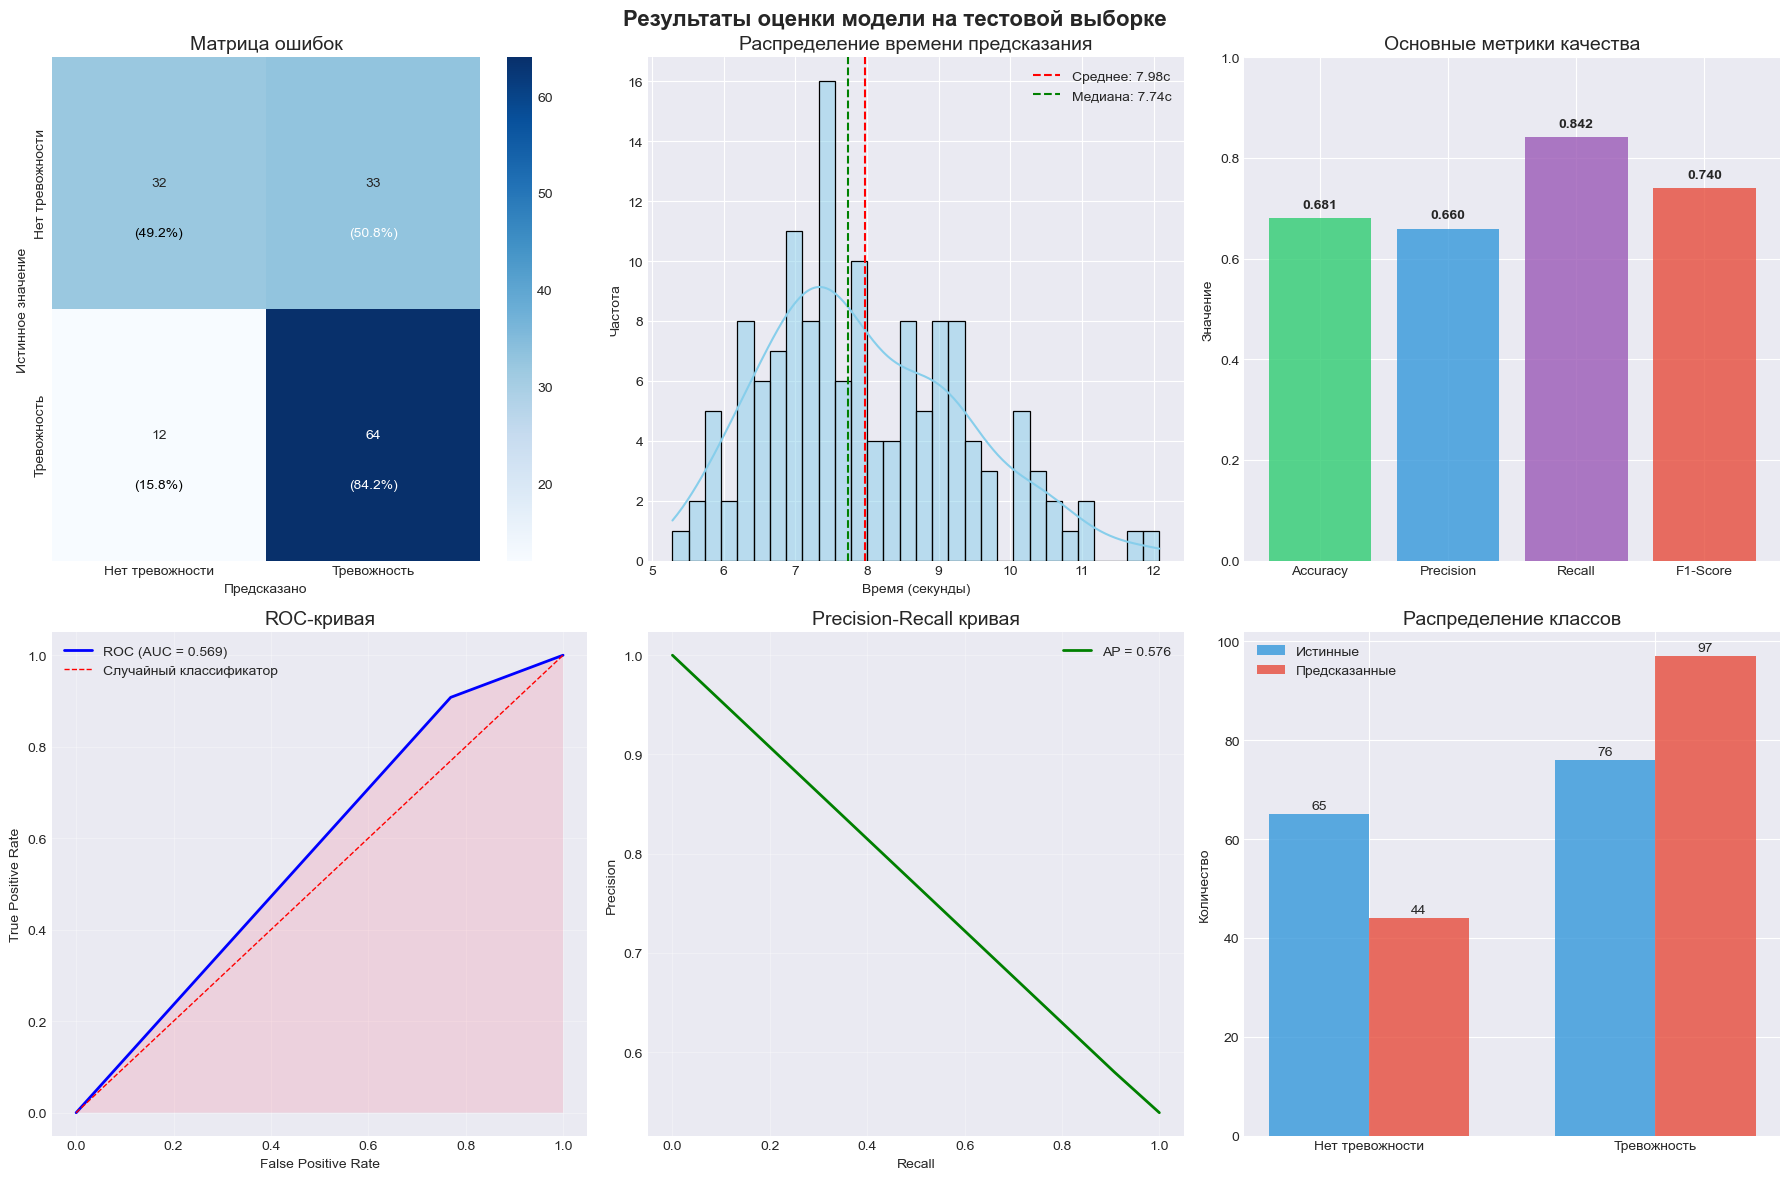


🔍 Анализ ошибок...


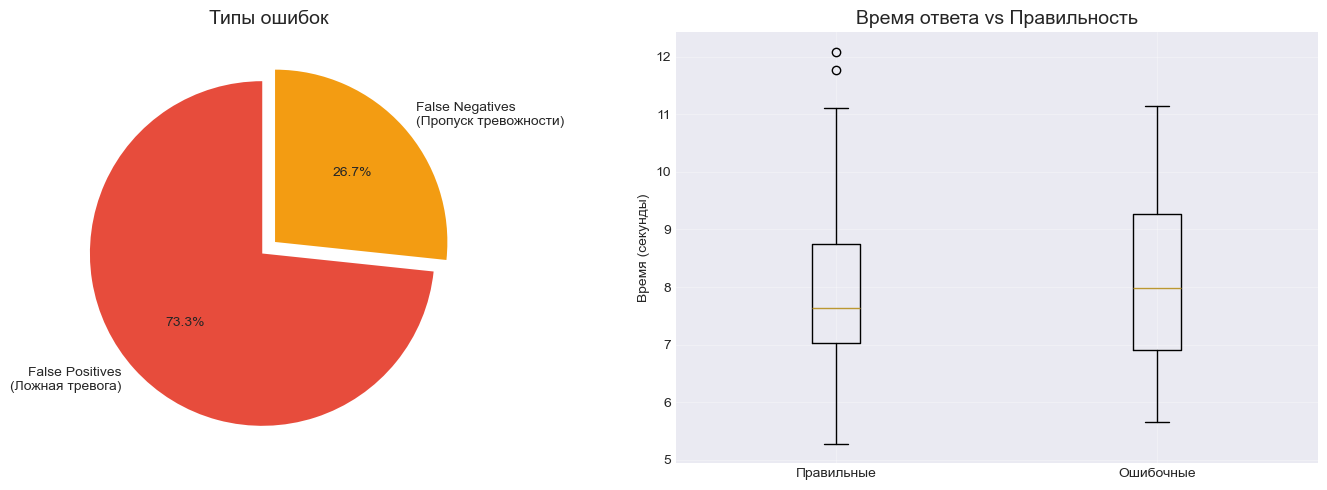


📝 Примеры ошибок модели:

Ложные срабатывания (False Positives) - модель предсказала тревожность, но её нет:

  Текст: Она посмотрела в окно и увидела свое отражение. Оно уже давно перестало ее пугать   мешки под глазами, болезненный вид. Эти морщины появились слишком ...
  Ответ модели: system
Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]...

  Текст: Привет! Как у тебя дела там — но это не точно, и в целом неважно.  по тебе скучаю, мне тебя не хватает! У меня все хорошо, учусь, до сих пор пытаюсь в...
  Ответ модели: system
Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:
Диагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]...

  Текст: Глобальный кризис - ситуация фундаментальной нестабильности и неопределенности, сейчас нас может развернуть случай   — но это не точно, и в целом нева...
  Ответ модели: system
Ты клинический психолог. Определи, 

In [1]:
# evaluate_model.py
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from datetime import datetime
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ============================================
print("📂 Загрузка тестовых данных...")

# Загружаем тестовые данные
X_test = pd.read_csv('anxiety_test_x_amplified.csv')
y_test = pd.read_csv('anxiety_test_y_amplified.csv')

# Объединяем
df_test = pd.concat([X_test, y_test], axis=1)
df_test.columns = ['text', 'label']

print(f"Загружено тестовых примеров: {len(df_test)}")
print(f"\nРаспределение классов в тесте:")
print(df_test['label'].value_counts())
print(f"\nПроцент положительных: {df_test['label'].value_counts(normalize=True).get('ТРЕВОЖНОСТЬ', 0)*100:.1f}%")

# Нормализуем метки
def normalize_label(label):
    label = str(label).upper().strip()
    return 'ТРЕВОЖНОСТЬ' if 'ТРЕВОЖНОСТЬ' in label else 'НЕТ ТРЕВОЖНОСТИ'

df_test['label'] = df_test['label'].apply(normalize_label)

# ============================================
# 2. ЗАГРУЗКА ОБУЧЕННОЙ МОДЕЛИ
# ============================================
print("\n🤖 Загрузка обученной модели...")

# Системный промпт (такой же, как при обучении)
system_prompt = "Ты клинический психолог. Определи, есть ли у пользователя признаки тревожности. Ответь строго в формате:\nДиагноз: [ТРЕВОЖНОСТЬ/НЕТ ТРЕВОЖНОСТИ]\nОбоснование: [1 предложение]"

# Загружаем модель (выберите нужный путь)
model_path = "./anxiety_model_full_classic"  # или "./anxiety_model_lora_classic"

try:
    # Пробуем загрузить полную модель
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        device_map="auto",
        torch_dtype=torch.float16,
    )
    print("✅ Загружена полная модель")
except:
    try:
        # Если полной нет, загружаем базовую + LoRA
        base_model_name = "Qwen/Qwen2.5-7B-Instruct"
        tokenizer = AutoTokenizer.from_pretrained(base_model_name)
        model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            device_map="auto",
            torch_dtype=torch.float16,
        )
        model = PeftModel.from_pretrained(model, model_path)
        print("✅ Загружена LoRA модель")
    except:
        raise Exception("Не удалось загрузить модель. Проверьте путь!")

tokenizer.pad_token = tokenizer.eos_token
model.eval()

# ============================================
# 3. ФУНКЦИЯ ПРЕДСКАЗАНИЯ
# ============================================
def predict_anxiety(text, max_length=512):
    """Предсказание тревожности для одного текста"""
    prompt = f"""<|im_start|>system
{system_prompt}<|im_end|>
<|im_start|>user
{text[:max_length]}<|im_end|>
<|im_start|>assistant
"""
    
    inputs = tokenizer(
        prompt, 
        return_tensors="pt", 
        truncation=True, 
        max_length=max_length
    ).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Извлекаем ответ ассистента
    if "<|im_start|>assistant" in response:
        response = response.split("<|im_start|>assistant")[-1].strip()
    
    return response

def extract_prediction(full_response):
    """Извлекает предсказанную метку из ответа модели (только после assistant)"""
    # Ищем последнюю метку assistant
    if 'assistant' in full_response.lower():
        # Берём только часть после последнего 'assistant'
        last_assistant = full_response.split('assistant')[-1]
    else:
        last_assistant = full_response
    
    # Анализируем только последний ответ модели
    if 'ДИАГНОЗ: ТРЕВОЖНОСТЬ' in last_assistant.upper():
        return 'ТРЕВОЖНОСТЬ'
    elif 'ДИАГНОЗ: НЕТ ТРЕВОЖНОСТИ' in last_assistant.upper():
        return 'НЕТ ТРЕВОЖНОСТИ'
    else:
        # fallback для старых форматов без "Диагноз:"
        if 'ТРЕВОЖНОСТЬ' in last_assistant.upper() and 'НЕТ ТРЕВОЖНОСТИ' not in last_assistant.upper():
            return 'ТРЕВОЖНОСТЬ'
        return 'НЕТ ТРЕВОЖНОСТИ'

def get_confidence(response):
    """Оценивает уверенность модели на основе ответа"""
    # Простая эвристика: считаем уверенность на основе наличия ключевых слов
    if 'явные' in response.lower() or 'отсутствуют' in response.lower():
        return 0.9
    elif 'возможно' in response.lower() or 'вероятно' in response.lower():
        return 0.7
    else:
        return 0.8  # Базовая уверенность

# ============================================
# 4. ЗАПУСК ПРЕДСКАЗАНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ
# ============================================
print(f"\n🔮 Запуск предсказаний на {len(df_test)} примерах...")
print("Это может занять несколько минут...\n")

predictions = []
confidences = []
true_labels = []
response_times = []
raw_responses = []

# Прогресс-бар
for idx, row in tqdm(df_test.iterrows(), total=len(df_test), desc="Предсказания"):
    text = row['text']
    true_label = row['label']
    
    # Замеряем время предсказания
    start_time = time.time()
    response = predict_anxiety(text)
    end_time = time.time()
    
    # Извлекаем предсказание
    pred_label = extract_prediction(response)
    confidence = get_confidence(response)
    
    # Сохраняем результаты
    predictions.append(pred_label)
    confidences.append(confidence)
    true_labels.append(true_label)
    response_times.append(end_time - start_time)
    raw_responses.append(response)
    
    # Выводим пример каждые 50 предсказаний
    if (idx + 1) % 50 == 0:
        print(f"\n📝 Пример {idx+1}:")
        print(f"Текст: {text[:100]}...")
        print(f"Истинная: {true_label} | Предсказано: {pred_label}")
        print(f"Время: {end_time - start_time:.2f}с")

# ============================================
# 5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
print("\n💾 Сохранение результатов...")

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'text': df_test['text'],
    'true_label': true_labels,
    'predicted_label': predictions,
    'confidence': confidences,
    'response_time': response_times,
    'raw_response': raw_responses
})

# Сохраняем в CSV
results_df.to_csv('prediction_results.csv', index=False)
print("✅ Результаты сохранены в prediction_results.csv")

# ============================================
# 6. ВЫЧИСЛЕНИЕ МЕТРИК
# ============================================
print("\n📊 Вычисление метрик...")

# Бинаризуем метки (1 = ТРЕВОЖНОСТЬ, 0 = НЕТ ТРЕВОЖНОСТИ)
y_true_binary = [1 if label == 'ТРЕВОЖНОСТЬ' else 0 for label in true_labels]
y_pred_binary = [1 if label == 'ТРЕВОЖНОСТЬ' else 0 for label in predictions]

# Основные метрики
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, pos_label='ТРЕВОЖНОСТЬ')
recall = recall_score(true_labels, predictions, pos_label='ТРЕВОЖНОСТЬ')
f1 = f1_score(true_labels, predictions, pos_label='ТРЕВОЖНОСТЬ')

# Специфичность
tn, fp, fn, tp = confusion_matrix(true_labels, predictions, labels=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ']).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# ROC-AUC (используем confidence как скор)
roc_auc = roc_auc_score(y_true_binary, confidences)

# ============================================
# 7. ОТЧЕТ
# ============================================
report = classification_report(
    true_labels, 
    predictions,
    target_names=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ'],
    output_dict=True
)

print("\n" + "="*60)
print("               РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ")
print("="*60)

print(f"\n📈 Основные метрики:")
print(f"  Accuracy (точность):     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision (точность):    {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall (полнота):        {recall:.4f} ({recall*100:.2f}%)")
print(f"  Specificity:             {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  F1-score:                {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC:                 {roc_auc:.4f}")

print(f"\n📊 Матрица ошибок:")
print(f"  True Negatives:  {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives:  {tp}")

print(f"\n⚡ Производительность:")
print(f"  Среднее время предсказания: {np.mean(response_times):.3f}с")
print(f"  Медианное время:           {np.median(response_times):.3f}с")
print(f"  Min/Max:                  {np.min(response_times):.3f}с / {np.max(response_times):.3f}с")
print(f"  Всего примеров:           {len(df_test)}")

print(f"\n📋 Classification Report:")
print(classification_report(true_labels, predictions, target_names=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ']))

# Сохраняем отчет в JSON
with open('evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump({
        'metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1_score': f1,
            'roc_auc': roc_auc,
        },
        'confusion_matrix': {
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
        },
        'performance': {
            'mean_time': float(np.mean(response_times)),
            'median_time': float(np.median(response_times)),
            'total_examples': len(df_test),
        },
        'classification_report': report,
        'timestamp': datetime.now().isoformat(),
    }, f, ensure_ascii=False, indent=2)

print("✅ Отчет сохранен в evaluation_report.json")

# ============================================
# 8. ВИЗУАЛИЗАЦИЯ
# ============================================
print("\n📈 Создание визуализаций...")

# Создаем папку для графиков
os.makedirs('plots', exist_ok=True)

# 8.1 Матрица ошибок
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Результаты оценки модели на тестовой выборке', fontsize=16, fontweight='bold')

# Матрица ошибок
ax = axes[0, 0]
cm = confusion_matrix(true_labels, predictions, labels=['НЕТ ТРЕВОЖНОСТИ', 'ТРЕВОЖНОСТЬ'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Нет тревожности', 'Тревожность'],
            yticklabels=['Нет тревожности', 'Тревожность'])
ax.set_title('Матрица ошибок', fontsize=14)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинное значение')

# Добавляем проценты в матрицу
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.7, f'({cm_norm[i,j]:.1%})',
                ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')

# 8.2 Распределение времени ответа
ax = axes[0, 1]
sns.histplot(response_times, bins=30, kde=True, ax=ax, color='skyblue')
ax.axvline(np.mean(response_times), color='red', linestyle='--', label=f'Среднее: {np.mean(response_times):.2f}с')
ax.axvline(np.median(response_times), color='green', linestyle='--', label=f'Медиана: {np.median(response_times):.2f}с')
ax.set_title('Распределение времени предсказания', fontsize=14)
ax.set_xlabel('Время (секунды)')
ax.set_ylabel('Частота')
ax.legend()

# 8.3 Сравнение метрик
ax = axes[0, 2]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = ax.bar(metrics, values, color=colors, alpha=0.8)
ax.set_ylim(0, 1)
ax.set_title('Основные метрики качества', fontsize=14)
ax.set_ylabel('Значение')

# Добавляем значения на столбцы
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{value:.3f}', ha='center', fontweight='bold')

# 8.4 ROC-кривая
ax = axes[1, 0]
fpr, tpr, _ = roc_curve(y_true_binary, confidences)
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайный классификатор')
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривая', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# 8.5 Precision-Recall кривая
ax = axes[1, 1]
precision_curve, recall_curve, _ = precision_recall_curve(y_true_binary, confidences)
ap = average_precision_score(y_true_binary, confidences)
ax.plot(recall_curve, precision_curve, 'g-', linewidth=2, label=f'AP = {ap:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривая', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# 8.6 Распределение классов
ax = axes[1, 2]
class_counts = df_test['label'].value_counts()
pred_counts = pd.Series(predictions).value_counts()

x = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, [class_counts.get('НЕТ ТРЕВОЖНОСТИ', 0), 
                              class_counts.get('ТРЕВОЖНОСТЬ', 0)],
               width, label='Истинные', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, [pred_counts.get('НЕТ ТРЕВОЖНОСТИ', 0),
                              pred_counts.get('ТРЕВОЖНОСТЬ', 0)],
               width, label='Предсказанные', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Нет тревожности', 'Тревожность'])
ax.set_title('Распределение классов', fontsize=14)
ax.set_ylabel('Количество')
ax.legend()

# Добавляем значения
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{int(height)}', ha='center')

plt.tight_layout()
plt.savefig('plots/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 9. ДОПОЛНИТЕЛЬНЫЙ ГРАФИК: Анализ ошибок
# ============================================
print("\n🔍 Анализ ошибок...")

# Находим ошибочные предсказания
errors = results_df[results_df['true_label'] != results_df['predicted_label']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Типы ошибок
ax = axes[0]
false_positives = len(errors[errors['true_label'] == 'НЕТ ТРЕВОЖНОСТИ'])
false_negatives = len(errors[errors['true_label'] == 'ТРЕВОЖНОСТЬ'])
error_types = ['False Positives\n(Ложная тревога)', 'False Negatives\n(Пропуск тревожности)']
error_counts = [false_positives, false_negatives]
ax.pie(error_counts, labels=error_types, autopct='%1.1f%%', 
       colors=['#e74c3c', '#f39c12'], startangle=90, explode=(0.05, 0.05))
ax.set_title('Типы ошибок', fontsize=14)

# Время ответа для правильных и ошибочных
ax = axes[1]
correct_mask = results_df['true_label'] == results_df['predicted_label']
ax.boxplot([results_df[correct_mask]['response_time'], 
            results_df[~correct_mask]['response_time']],
           labels=['Правильные', 'Ошибочные'])
ax.set_title('Время ответа vs Правильность', fontsize=14)
ax.set_ylabel('Время (секунды)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 10. ПРИМЕРЫ ОШИБОК
# ============================================
print("\n📝 Примеры ошибок модели:")

print("\nЛожные срабатывания (False Positives) - модель предсказала тревожность, но её нет:")
fp_examples = errors[errors['true_label'] == 'НЕТ ТРЕВОЖНОСТИ'].head(3)
for idx, row in fp_examples.iterrows():
    print(f"\n  Текст: {row['text'][:150]}...")
    print(f"  Ответ модели: {row['raw_response'][:150]}...")

print("\nПропуски (False Negatives) - модель не заметила тревожность:")
fn_examples = errors[errors['true_label'] == 'ТРЕВОЖНОСТЬ'].head(3)
for idx, row in fn_examples.iterrows():
    print(f"\n  Текст: {row['text'][:150]}...")
    print(f"  Ответ модели: {row['raw_response'][:150]}...")

# ============================================
# 11. ИТОГОВОЕ РЕЗЮМЕ
# ============================================
print("\n" + "="*60)
print("                  ИТОГОВОЕ РЕЗЮМЕ")
print("="*60)

print(f"""
📊 Ключевые показатели:
  • Accuracy (общая точность): {accuracy:.2%}
  • F1-Score (сбалансированность): {f1:.2%}
  • ROC-AUC (качество разделения): {roc_auc:.3f}

🎯 Надежность:
  • Правильно классифицировано: {accuracy*len(df_test):.0f} из {len(df_test)}
  • Ложных тревог: {false_positives} ({false_positives/len(df_test)*100:.1f}%)
  • Пропусков тревожности: {false_negatives} ({false_negatives/len(df_test)*100:.1f}%)

⚡ Скорость:
  • Среднее время: {np.mean(response_times):.2f}с
  • Медианное время: {np.median(response_times):.2f}с

📁 Сохраненные файлы:
  • prediction_results.csv - все предсказания
  • evaluation_report.json - детальный отчет
  • plots/evaluation_results.png - основные графики
  • plots/error_analysis.png - анализ ошибок
""")

print("✅ Оценка модели завершена!")